In [9]:
import pandas as pd
data= pd.read_csv(r'online_retail.csv')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print(data.shape)

(541909, 8)


In [15]:
data=data.dropna(subset=['CustomerID'])  

In [17]:
data= data[~data['InvoiceNo'].str.startswith('C')]

In [22]:
# Remove negative or zero quantities and prices
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


In [23]:
# Remove outliers in Quantity and UnitPrice using IQR
Q1 = data[['Quantity', 'UnitPrice']].quantile(0.25)
Q3 = data[['Quantity', 'UnitPrice']].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within 1.5*IQR of Q1 and Q3
data = data[
    ((data['Quantity'] >= (Q1['Quantity'] - 1.5 * IQR['Quantity'])) & 
     (data['Quantity'] <= (Q3['Quantity'] + 1.5 * IQR['Quantity']))) &
    ((data['UnitPrice'] >= (Q1['UnitPrice'] - 1.5 * IQR['UnitPrice'])) & 
     (data['UnitPrice'] <= (Q3['UnitPrice'] + 1.5 * IQR['UnitPrice'])))
]

In [26]:
# RFM analysis
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
display(snapshot_date)
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})


Timestamp('2023-12-10 12:50:00')

In [28]:
display(rfm.head(10))

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12347.0,2,7,3314.73
12348.0,249,3,90.20
12349.0,19,1,999.15
12350.0,310,1,294.40
12352.0,36,7,1130.94
12353.0,204,1,29.30
12354.0,232,1,682.69
12355.0,214,1,219.00
12356.0,246,2,1086.56


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,3314.73
12348.0,249,3,90.20
12349.0,19,1,999.15
12350.0,310,1,294.40
12352.0,36,7,1130.94


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

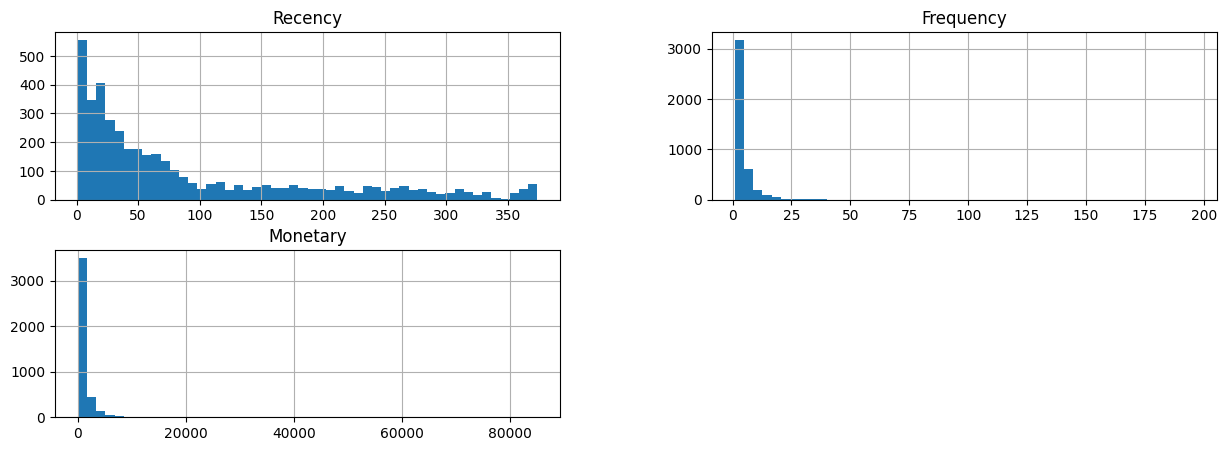

In [29]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
display(rfm.head())
rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=50, figsize=(15,5))

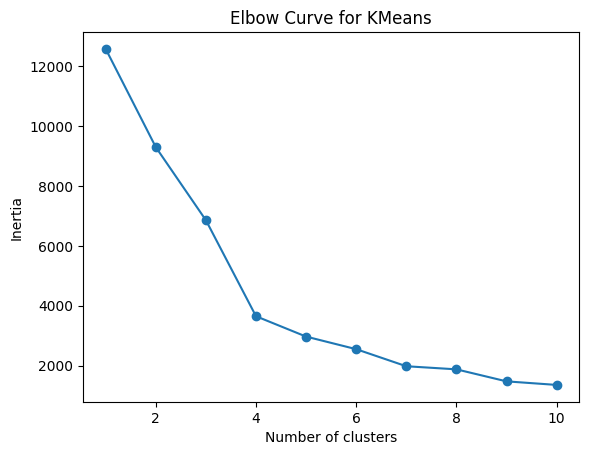

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_scaled = StandardScaler().fit_transform(rfm)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve for KMeans')
plt.show()

In [31]:
# Assuming optimal k from elbow curve, e.g., k=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
cluster_profiles = rfm.groupby('Cluster').mean()
print(cluster_profiles)

            Recency   Frequency      Monetary
Cluster                                      
0         43.755903    3.413542    841.930428
1          2.000000  148.000000  43780.440000
2         13.379310   18.444444   5342.485517
3        246.770554    1.519120    310.317793


In [32]:
# Calculate Recency for each customer
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)
print(recency.head())

CustomerID
12347.0      2
12348.0    249
12349.0     19
12350.0    310
12352.0     36
Name: InvoiceDate, dtype: int64


In [37]:
display(rfm['Recency'].head())

CustomerID
12347.0      2
12348.0    249
12349.0     19
12350.0    310
12352.0     36
Name: Recency, dtype: int64

In [38]:
# Calculate Frequency: Number of transactions per customer
frequency = data.groupby('CustomerID')['InvoiceNo'].nunique()
print(frequency.head())

CustomerID
12347.0    7
12348.0    3
12349.0    1
12350.0    1
12352.0    7
Name: InvoiceNo, dtype: int64


In [39]:
# Calculate Monetary: Total amount spent by customer
monetary = data.groupby('CustomerID')['TotalPrice'].sum()
print(monetary.head())

CustomerID
12347.0    3314.73
12348.0      90.20
12349.0     999.15
12350.0     294.40
12352.0    1130.94
Name: TotalPrice, dtype: float64


In [40]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# rfm_scaled is now a numpy array with standardized RFM values
print(rfm_scaled[:5])

[[-0.90586814  0.42552448  1.03578802]
 [ 1.56668705 -0.14465315 -0.42638631]
 [-0.73569228 -0.42974197 -0.01421977]
 [ 2.17731809 -0.42974197 -0.33379111]
 [-0.56551641  0.42552448  0.04554086]]


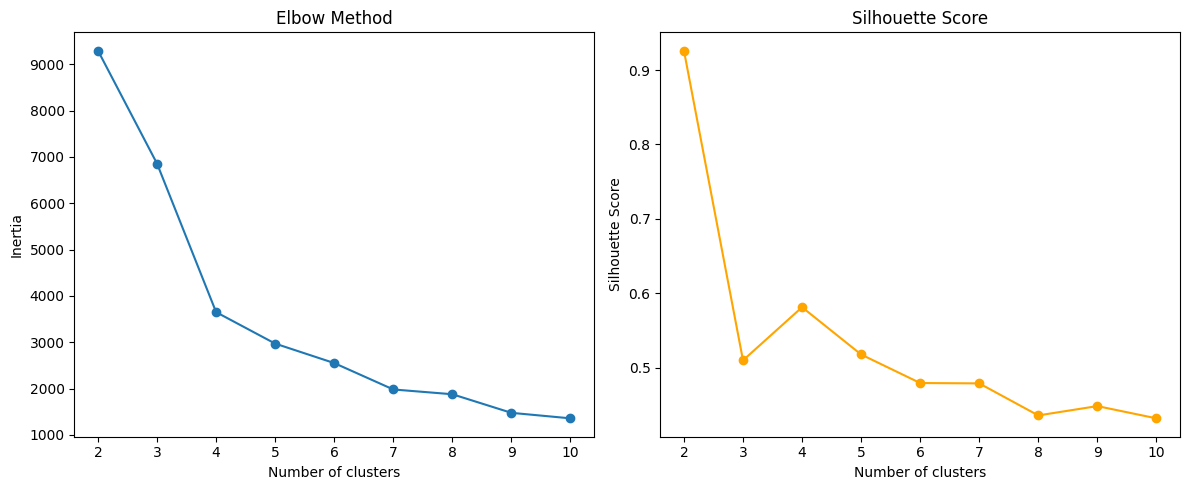

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters for silhouette score

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

In [42]:
# Run KMeans clustering with optimal k (e.g., k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Calculate cluster averages
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_profiles)

            Recency   Frequency      Monetary
Cluster                                      
0         43.755903    3.413542    841.930428
1          2.000000  148.000000  43780.440000
2         13.379310   18.444444   5342.485517
3        246.770554    1.519120    310.317793


In [43]:
# Label clusters based on RFM averages
def label_cluster(row):
    if row['Recency'] < cluster_profiles['Recency'].mean() and \
       row['Frequency'] > cluster_profiles['Frequency'].mean() and \
       row['Monetary'] > cluster_profiles['Monetary'].mean():
        return 'High-Value'
    elif row['Frequency'] > cluster_profiles['Frequency'].median() and \
         row['Monetary'] > cluster_profiles['Monetary'].median():
        return 'Regular'
    elif row['Frequency'] < cluster_profiles['Frequency'].median() and \
         row['Monetary'] < cluster_profiles['Monetary'].median() and \
         row['Recency'] > cluster_profiles['Recency'].median():
        return 'Occasional'
    else:
        return 'At-Risk'

In [45]:
rfm['Segment'] = rfm.apply(label_cluster, axis=1)
print(rfm[['Cluster', 'Segment']].head(10))

            Cluster     Segment
CustomerID                     
12347.0           0     At-Risk
12348.0           3  Occasional
12349.0           0     At-Risk
12350.0           3  Occasional
12352.0           0  Occasional
12353.0           3  Occasional
12354.0           3  Occasional
12355.0           3  Occasional
12356.0           3  Occasional
12357.0           0     At-Risk


In [46]:
print(rfm[['Cluster', 'Segment']].head(100))

            Cluster     Segment
CustomerID                     
12347.0           0     At-Risk
12348.0           3  Occasional
12349.0           0     At-Risk
12350.0           3  Occasional
12352.0           0  Occasional
...             ...         ...
12463.0           0  Occasional
12464.0           3  Occasional
12465.0           0     At-Risk
12468.0           3  Occasional
12471.0           2     Regular

[100 rows x 2 columns]


In [47]:
pivot = data.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)
display(pivot.head())


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,TRELLIS COAT RACK,10 COLOUR SPACEBOY PEN,...,ZINC PLANT POT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12352.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
product_names = list(pivot.columns)
display(product_names[:10])

[' 4 PURPLE FLOCK DINNER CANDLES',
 " 50'S CHRISTMAS GIFT BAG LARGE",
 ' DOLLY GIRL BEAKER',
 ' I LOVE LONDON MINI BACKPACK',
 ' I LOVE LONDON MINI RUCKSACK',
 ' OVAL WALL MIRROR DIAMANTE ',
 ' RED SPOT GIFT BAG LARGE',
 ' SET 2 TEA TOWELS I LOVE LONDON ',
 ' TRELLIS COAT RACK',
 '10 COLOUR SPACEBOY PEN']

In [49]:
from sklearn.metrics.pairwise import cosine_similarity
product_similarity = cosine_similarity(pivot.T)
display(product_similarity[:5, :5])

array([[1.00000000e+00, 0.00000000e+00, 2.07009879e-04, 7.42883827e-04,
        0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 4.20275593e-02, 4.09433029e-02,
        0.00000000e+00],
       [2.07009879e-04, 4.20275593e-02, 1.00000000e+00, 1.33523211e-01,
        8.04413862e-03],
       [7.42883827e-04, 4.09433029e-02, 1.33523211e-01, 1.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.04413862e-03, 0.00000000e+00,
        1.00000000e+00]])